# A scene

One tile of the LLC4320 grid: the squared buoyancy gradient field, every
front found in it, and a row per front.

Everything is in the one NetCDF. It needs only `xarray`, `numpy` and
`matplotlib` -- no `front-finding` install, no S3 access.

| file | |
|---|---|
| `fronts_tile330_*.nc` | the scene: field, front map, per-front table |
| `fronts_tile330_*_labels.npy` | the label map alone -- same as `ds["labels"]` |

Set `DATA_DIR` below to wherever you saved them.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import xarray as xr

# ---------------------------------------------------------------- edit me --
DATA_DIR = Path("../output/SCENE330/OSN/scenes/")                                  # where the files are
SCENE    = "fronts_tile330_20120629_000000.nc"        # which scene
# ---------------------------------------------------------------------------

path = Path(DATA_DIR).expanduser() / SCENE
if not path.is_file():
    found = sorted(p.name for p in Path(DATA_DIR).expanduser().glob("*.nc"))
    raise FileNotFoundError(
        f"no {SCENE} in {Path(DATA_DIR).expanduser().resolve()}\n"
        + (f"NetCDFs there: {found}" if found else "no NetCDFs there at all"))

ds = xr.open_dataset(path)
ds

<xarray.Dataset> Size: 5MB
Dimensions:              (j: 720, i: 720, front: 318)
Dimensions without coordinates: j, i, front
Data variables: (12/22)
    gradb2               (j, i) float32 2MB ...
    binary               (j, i) int8 518kB ...
    labels               (j, i) int32 2MB ...
    label                (front) int32 1kB ...
    name                 (front) <U29 37kB ...
    time                 (front) <U19 24kB ...
    ...                   ...
    lat_min              (front) float32 1kB ...
    lat_max              (front) float32 1kB ...
    lon_min              (front) float32 1kB ...
    lon_max              (front) float32 1kB ...
    mean_curvature       (front) float32 1kB ...
    curvature_direction  (front) float32 1kB ...
Attributes:
    date_prefix:     20120629_000000
    timestamp:       2012-06-29T00:00:00
    window:          [ 9360 10080 12960 13680]
    rect_j_start:    9360
    rect_i_start:    12960
    n_fronts:        318
    gradb2_channel:  gradb2
    source_store:    /home/lhoffma2/git/front-finding/output/SCENE330/OSN/fro...
    build_version:   SCENE330
    finding_config:  D

## What is in it

In [15]:
ny, nx = ds["labels"].shape
print(f"{ny} x {nx} pixels, {ds.sizes['front']} fronts")
print(f"snapshot  {ds.attrs['timestamp']}")
print(f"window    {tuple(int(v) for v in ds.attrs['window'])}  "
      f"on the 12960 x 17280 rect grid")
print(f"built by  {ds.attrs['build_version']}, finding config "
      f"{ds.attrs['finding_config']}")
print(f"from      {ds.attrs['source_store']}")

print("\nper-front columns:")
print([v for v in ds.data_vars if "front" in ds[v].dims])

720 x 720 pixels, 318 fronts
snapshot  2012-06-29T00:00:00
window    (9360, 10080, 12960, 13680)  on the 12960 x 17280 rect grid
built by  SCENE330, finding config D
from      /home/lhoffma2/git/front-finding/output/SCENE330/OSN/fronts.zarr

per-front columns:
['label', 'name', 'time', 'npix', 'y0', 'y1', 'x0', 'x1', 'centroid_lat', 'centroid_lon', 'length_km', 'orientation', 'num_branches', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'mean_curvature', 'curvature_direction']


## Does it hang together

The raster and the table are written from the same crop, so they should
agree exactly. If they do not, the scene is not usable as training data --
an unlabelled front is a false negative the detector gets punished for.

In [16]:
labels = ds["labels"].values
present = np.unique(labels[labels > 0])

assert set(present) == set(ds["label"].values), "raster and table disagree"
assert (ds["binary"].values.astype(bool) == (labels > 0)).all(), "binary != labels>0"
assert ds.sizes["front"] == len(present)
print(f"OK: each of {len(present)} labels in the raster has a row, and back")

finite = np.isfinite(ds["gradb2"].values)
print(f"gradb2 finite over {100 * finite.mean():.1f}% of the scene "
      f"(the rest is land, or ice if the build masked it)")

OK: each of 318 labels in the raster has a row, and back
gradb2 finite over 68.4% of the scene (the rest is land, or ice if the build masked it)


## The scene

gradb2 spans orders of magnitude, so it is drawn as `log10`. That is a
display choice only -- the stored values are raw.

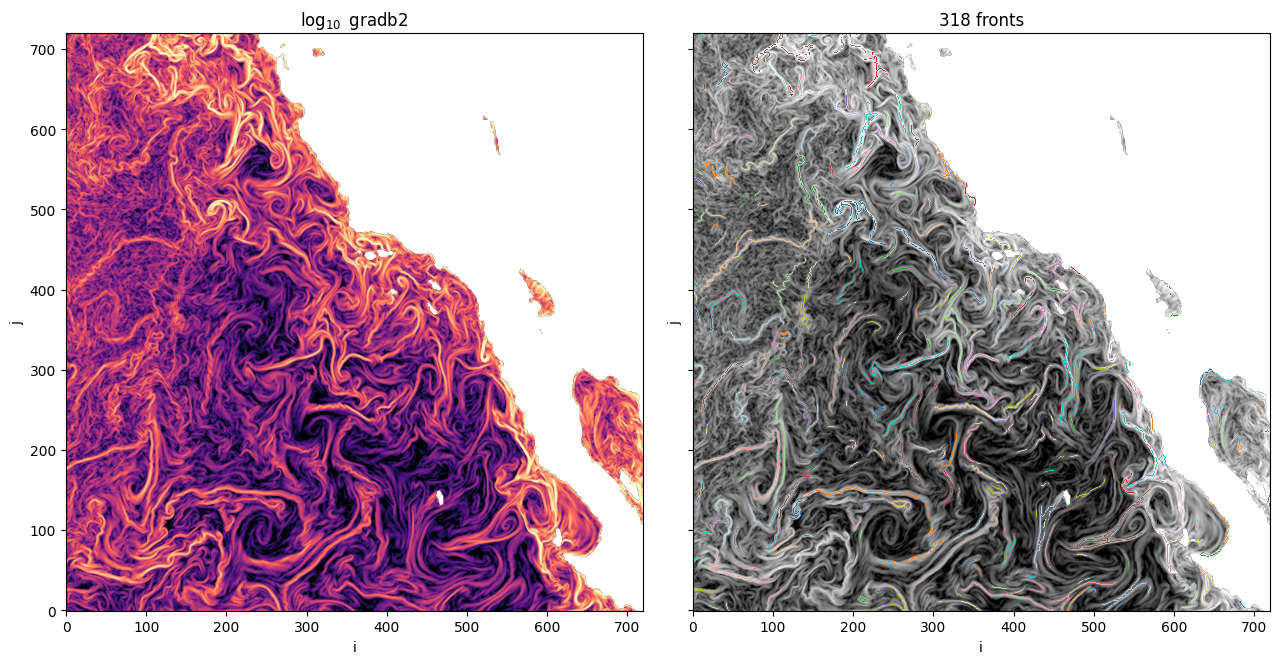

In [17]:
g = ds["gradb2"].values.astype(float)
with np.errstate(divide="ignore", invalid="ignore"):
    logg = np.log10(np.where(g > 0, g, np.nan))
lo, hi = np.nanpercentile(logg, [2, 99.5])

fig, axes = plt.subplots(1, 2, figsize=(13, 6.4), sharex=True, sharey=True)
axes[0].imshow(logg, origin="lower", vmin=lo, vmax=hi, cmap="magma")
axes[0].set_title(r"$\log_{10}$ gradb2")

axes[1].imshow(logg, origin="lower", vmin=lo, vmax=hi, cmap="gray")
# % 19 only so neighbouring labels get different colours.
axes[1].imshow(np.ma.masked_where(labels == 0, labels % 19 + 1),
               origin="lower", cmap="tab20", interpolation="nearest")
axes[1].set_title(f"{ds.sizes['front']} fronts")

for ax in axes:
    ax.set_xlabel("i"); ax.set_ylabel("j")
fig.tight_layout()

## The fronts

`length_km`, `orientation` and the centroid describe the **whole** front as
the global build measured it. A front crossing the window edge keeps the
global numbers while only part of it is in the picture -- compare `npix`
here against the pixels actually present if that matters to you.

In [18]:
cols = [v for v in ds.data_vars if "front" in ds[v].dims]
fronts = ds[cols].to_dataframe().set_index("label")   # index BY label
fronts[["npix", "length_km", "orientation", "num_branches"]].describe().round(2)

,npix,length_km,orientation,num_branches
count,318.00,318.00,318.00,318.00
mean,42.63,85.21,40.48,2.08
std,54.53,110.39,26.43,5.07
min,8.00,14.16,0.00,0.00
25%,12.00,24.57,17.17,0.00
50%,22.00,44.54,37.93,0.00
75%,43.00,87.68,63.74,0.00
max,322.00,723.74,90.00,38.00


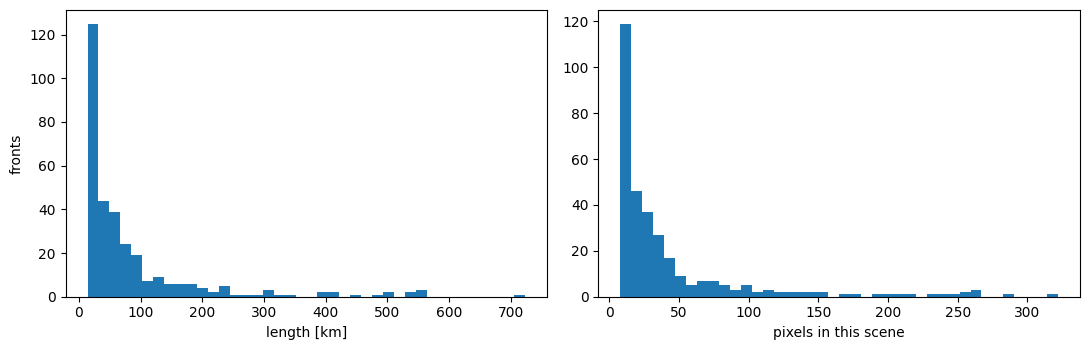

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(fronts["length_km"], bins=40)
axes[0].set_xlabel("length [km]"); axes[0].set_ylabel("fronts")
axes[1].hist(fronts["npix"], bins=40)
axes[1].set_xlabel("pixels in this scene")
fig.tight_layout()

## One front, close up

front 92335: 724 km, 322 px, centroid 27.59N -124.65E


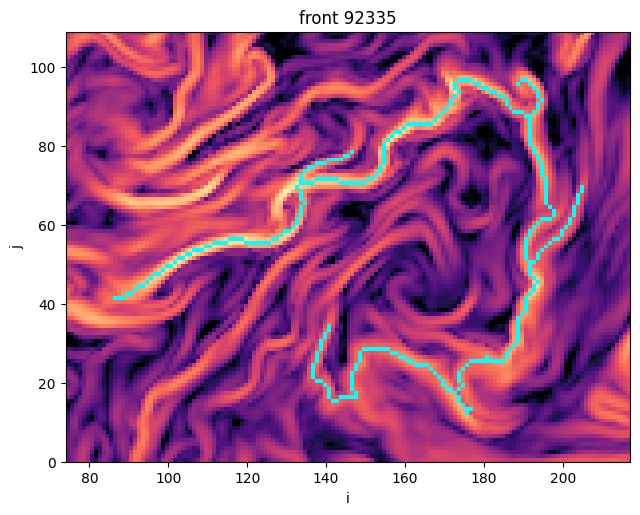

In [20]:
label = int(fronts["length_km"].idxmax())     # or pick any label
row = fronts.loc[label]
print(f"front {label}: {row['length_km']:.0f} km, {int(row['npix'])} px, "
      f"centroid {row['centroid_lat']:.2f}N {row['centroid_lon']:.2f}E")

ys, xs = np.nonzero(labels == label)
pad = 12
y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad + 1, ny)
x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad + 1, nx)

fig, ax = plt.subplots(figsize=(6.5, 6))
extent = [x0, x1, y0, y1]
ax.imshow(logg[y0:y1, x0:x1], origin="lower", vmin=lo, vmax=hi,
          cmap="magma", extent=extent)

# Draw the front's own pixels.  NOT contour(): a front is one pixel wide, so
# a contour traces both sides of it and comes back as a thin closed loop --
# the line looks doubled and hollow rather than drawn.
crop = labels[y0:y1, x0:x1]
ax.imshow(np.ma.masked_where(crop != label, np.ones_like(crop)),
          origin="lower", extent=extent, interpolation="nearest",
          cmap=ListedColormap(["cyan"]), vmin=0, vmax=1)

ax.set_title(f"front {label}"); ax.set_xlabel("i"); ax.set_ylabel("j")
fig.tight_layout()

## Boxes

The scene ships the label map, not boxes -- a detector may want masks, or
boxes, or both. Boxes fall out of the label map in three lines.

These are measured **in this image**, unlike `length_km` above.

In [21]:
rows = []
for lab in ds["label"].values:
    ys, xs = np.nonzero(labels == lab)
    by0, by1 = ys.min(), ys.max() + 1
    bx0, bx1 = xs.min(), xs.max() + 1
    rows.append([0,                                   # one class: 'front'
                 (bx0 + bx1) / 2 / nx, (by0 + by1) / 2 / ny,
                 (bx1 - bx0) / nx, (by1 - by0) / ny])
boxes = np.array(rows)

assert boxes[:, 1:].min() >= 0 and boxes[:, 1:].max() <= 1
np.savetxt(path.with_suffix(".txt"), boxes, fmt="%d %.6f %.6f %.6f %.6f")
print(f"{len(boxes)} boxes -> {path.with_suffix('.txt').name}")
boxes[:5].round(4)

318 boxes -> fronts_tile330_20120629_000000.txt


array([[0.    , 0.7438, 0.0403, 0.0819, 0.0806],
       [0.    , 0.9549, 0.0111, 0.0181, 0.0167],
       [0.    , 0.0347, 0.0076, 0.0194, 0.0069],
       [0.    , 0.0201, 0.0347, 0.0403, 0.0056],
       [0.    , 0.8549, 0.0069, 0.0181, 0.0028]])

## Sending it on

The NetCDF is self-contained -- the field, the front map and the table are
all in it, at a few MB for a 720 x 720 tile. Send that, plus the `.npy` from
`--npy` if integer IDs on their own are what was asked for.

Not the zarr store: that is the global build behind this scene, 224M pixels
per raster and ~117k fronts, and nothing in this scene needs it.

`labels` and `binary` are mostly zeros, so compressing costs nothing:

```python
enc = {v: {"zlib": True, "complevel": 4} for v in ("gradb2", "labels", "binary")}
ds.to_netcdf("scene_compressed.nc", encoding=enc)
```